# Random-direction lab: one trained network + 2 random directions per method
Pick, for each column, a method, a seed (0-9), two direction seeds and a radius, then run the cells.
Planes are cached in `figures/landscape/fig1/random_cache/`; anything not cached is computed by one
SLURM GPU job (FS methods need a GPU; the soft methods are also much faster there). Re-run the plot
cell when the job is done. Directions: filter-normalized Gaussian, drawn on the CPU from the given
torch seeds (identical for every method). Loss: each method's own training loss, held-out.
Colour: log10 relative to the method's best of its 10 trained networks (or `norm="center"`).

Methods: M1 SL rho 10, M4 SSL rho 10, M2 SL rho 1e5, M3f SL + hard FS (FSNet recipe),
M3r1 / M3r08 SL + hard FS with rho 1 / 0.8 (collapsed seeds: M3r1 1, 3, 8; M3r08 2, 5, 6, 7, 8).

In [58]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "2")  # login node: keep plotting light
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")
import importlib
import random_lab as R
importlib.reload(R)

N = 61  # grid points per axis (61 x 61; ~70 s per FS plane on an H200, seconds for the others)

In [59]:
# One entry per column: (method, dict(seed=, dirs=(a, b), radius=, scale=(sa, sb))). The same method may
# appear twice. scale (optional, default (1, 1)) stretches each direction: the plane is
# theta + x * sa * d_a + y * sb * d_b for x, y in [-radius, radius]; axes are shown in units of d_a, d_b.
CHOICES = [
    ("M1",    dict(seed=5, dirs=(3, 2), radius=20.0)),
    # ("M4",    dict(seed=3, dirs=(0, 1), radius=1.0)),
    ("M2",    dict(seed=6, dirs=(5, 10), radius=20.0)),
    # ("M3f",   dict(seed=3, dirs=(0, 1), radius=1.0)),
    # ("M3r1",  dict(seed=4, dirs=(0, 1), radius=1.0)),  # good seed
    # ("M3r1",  dict(seed=3, dirs=(0, 1), radius=1.0)),  # collapsed seed
    # ("M3f", dict(seed=3, dirs=(0, 1), radius=1.0, scale=(3, 1))),  # stretch direction 0 by 3x
]

In [60]:
# Submit one GPU job for every plane not cached yet (returns None if all are cached).
job = R.submit(R.specs(CHOICES), n=N)
print("job:", job, "|", R.status(job))

job: 24446859 | pending


In [66]:
# Check the job; re-run this cell until it says "done", then plot.
print(R.status(job))

done


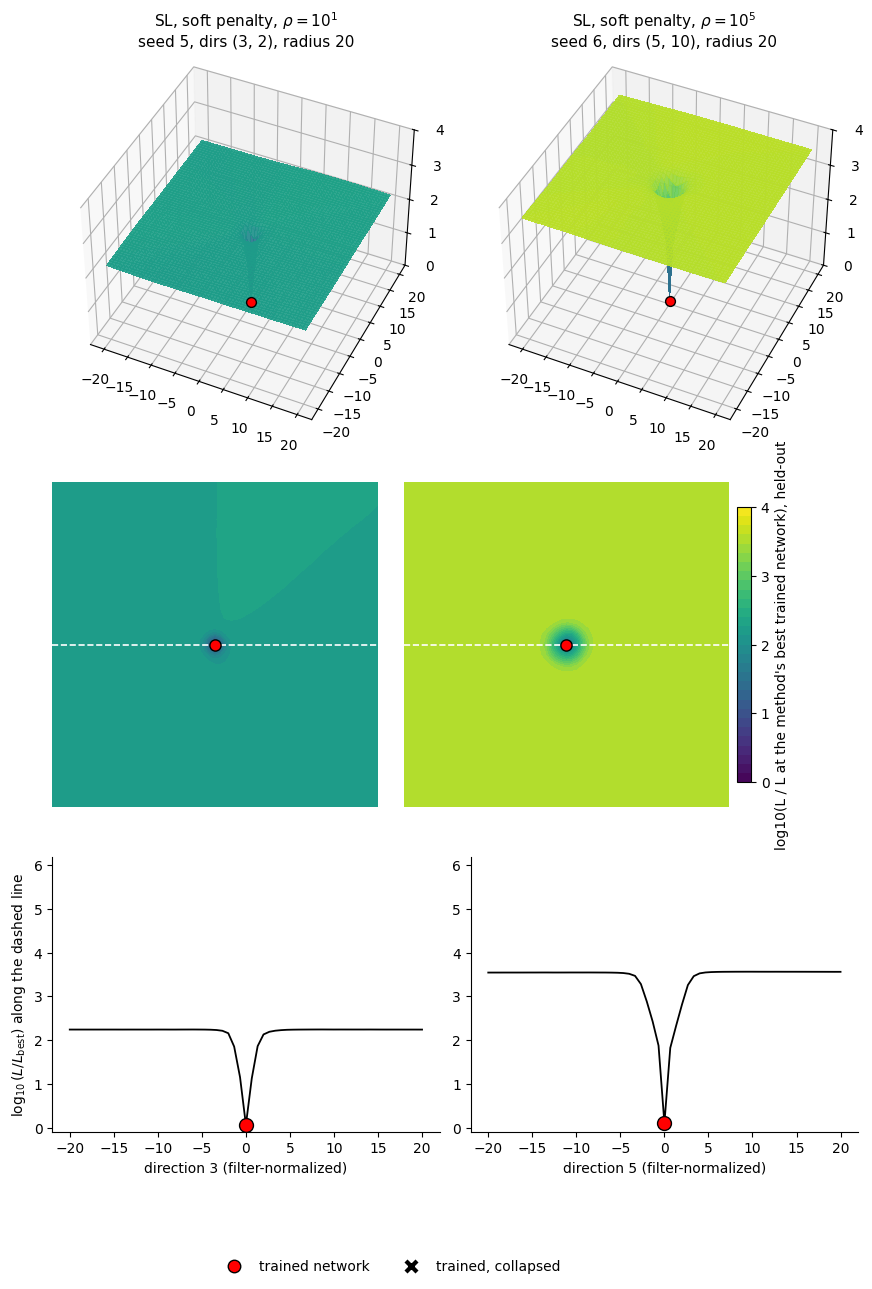

In [67]:
fig = R.figure(CHOICES, n=N)  # options: cap=4, norm="method" | "center", elev=42, azim=-65, path="x.png"

In [63]:
# Radius sweep for one method (same seed and directions), e.g. to see where hard FS hits its cliff.
SWEEP = [("M3f", dict(seed=3, dirs=(0, 1), radius=r)) for r in (0.3, 1.0, 3.0)]
job2 = R.submit(R.specs(SWEEP), n=N)
print("job:", job2, "|", R.status(job2))

job: None | done


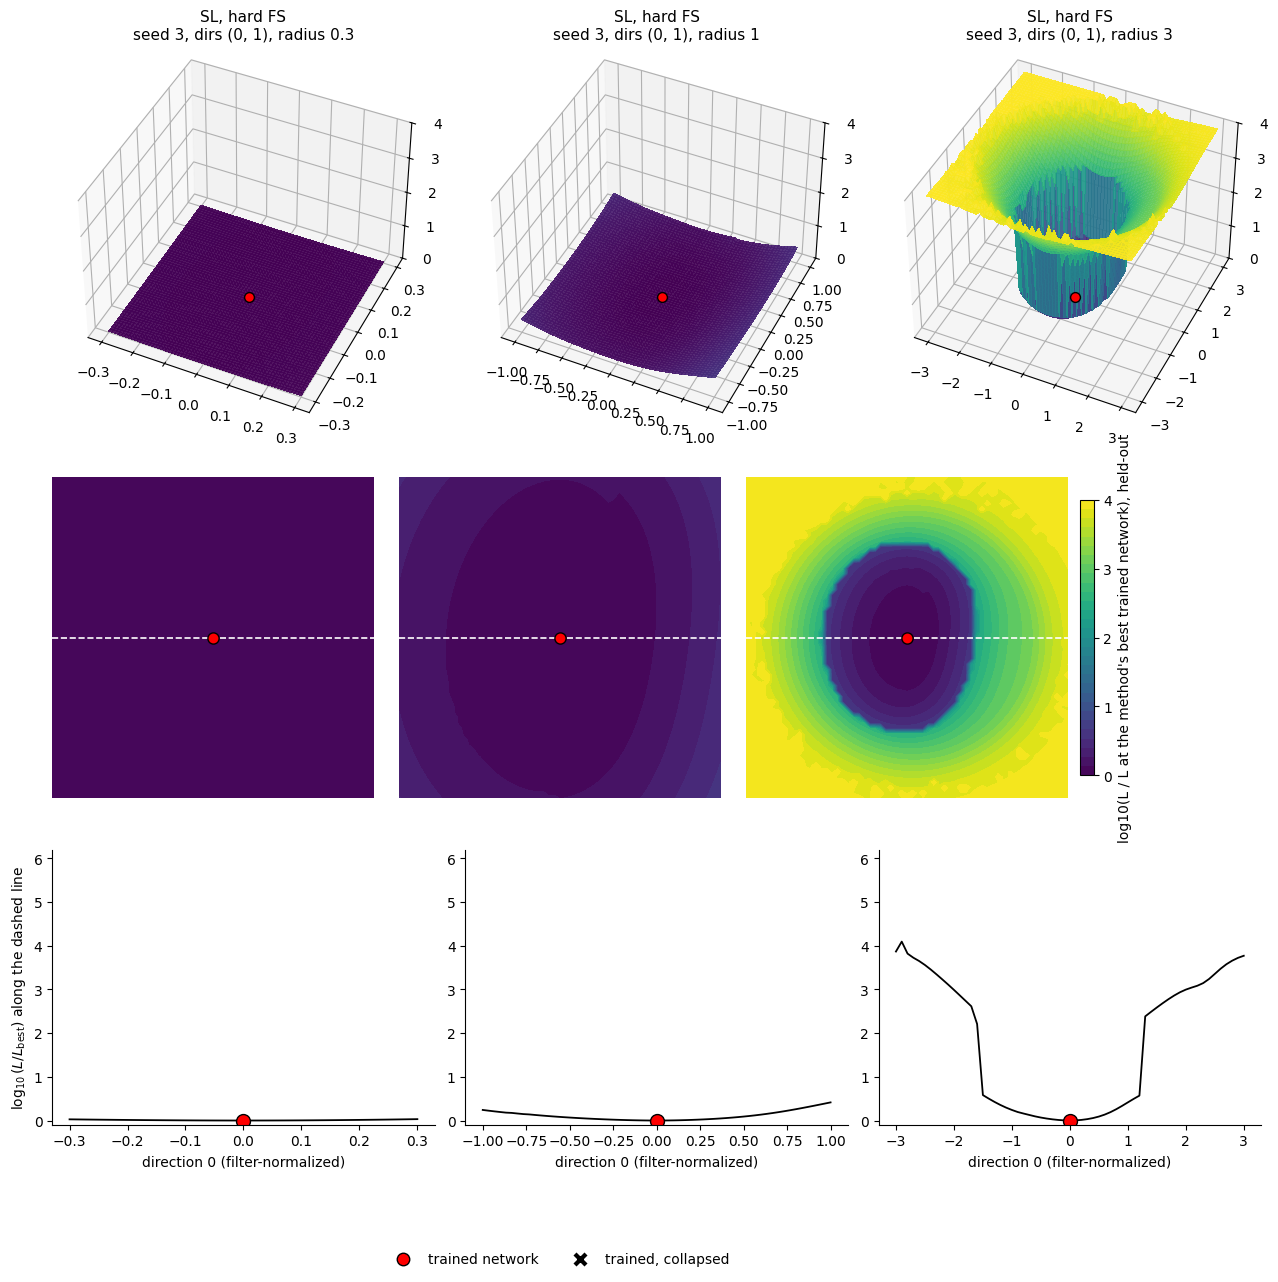

In [64]:
fig = R.figure(SWEEP, n=N)

In [65]:
# Small grids can be computed right here on the login node for the soft methods (not FS):
# R.compute("M1", 3, (0, 1), 1.0, n=21); fig = R.figure([("M1", dict(seed=3, dirs=(0, 1), radius=1.0))], n=21)